# Rijksmuseum Explorer — Local Analytics Overview

This notebook explores a small sample of **local analytics events**
collected by the *Rijksmuseum Explorer* prototype.

Goal:
- Show what kind of insights the museum could get from usage data,
  without sending any personal information to external servers.
- Demonstrate how the same raw export can be used both in tools like
  **Power BI / Tableau** and in a **Python notebook** for deeper analysis.
- Start from the **raw CSV** (with a `props_json` column) and expand it
  into a richer analytics table with one column per property.

We will:
1. Load the raw analytics CSV file (with `timestamp`, `event`, `page`, `props_json`).
2. Parse and expand the JSON in `props_json` into multiple `prop_*` columns.
3. Get an overview of event types and app pages.
4. Explore search behaviour (queries, filters, result counts).
5. Explore artwork views (artists and object IDs).
6. Look at notes and PDF export behaviour.
7. Summarize key findings in a short human-readable report that could
   be reused in a slide deck or internal memo.

###1.Import dataset

In [18]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Se estiver rodando em notebook integrado ao PyCharm, não precisa do %matplotlib inline,
# mas não atrapalha se estiver usando Jupyter.
# %matplotlib inline

# Este notebook está em: analytics/notebook/
# O CSV está em:         analytics/events_data/rijks_explorer_events_25_02_26.csv
DATA_PATH = Path("..") / "events_data" / "rijks_explorer_events_25_02_26.csv"

print("Current working dir:", Path.cwd())
print("Resolved CSV path:", DATA_PATH.resolve())

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found at: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
print("Raw columns:", df_raw.columns.tolist())
df_raw.head()

Current working dir: /Users/arnaldomarianocarmona/PycharmProjects/app_museum_submission/analytics/notebook
Resolved CSV path: /Users/arnaldomarianocarmona/PycharmProjects/app_museum_submission/analytics/events_data/rijks_explorer_events_25_02_26.csv
Raw shape: (652, 4)
Raw columns: ['timestamp', 'event', 'page', 'props_json']


,timestamp,event,page,props_json
0,NaN,page_view,Explorer,"{""has_favorites"": true, ""favorites_count"": 33}"
1,NaN,page_view,PDF_Setup,"{""has_existing_config"": true}"
2,NaN,compare_clicked,Compare,"{""object_id_a"": ""SK-C-5"", ""object_id_b"": ""SK-A..."
3,NaN,page_view,Statistics,{}
4,NaN,compare_clicked,Compare,"{""object_id_a"": ""SK-C-5"", ""object_id_b"": ""SK-A..."


### Quick inspection of the `props_json` column

Before we expand the JSON into separate columns, it is useful to quickly
inspect a few raw values from the `props_json` field.

Here we:
- print the **Python type** of each cell (usually `str` or `float` if it is `NaN`);
- print a short **string representation** of the content.

This helps to:
- confirm that the column really contains JSON strings,
- see what kind of keys exist inside `props_json` (e.g. `query_sample`, `object_id`, `artist`, …),
- detect any unexpected or malformed rows before normalization.

In [19]:
# Quick look at the props_json column
print("Sample from props_json:")
for i in range(5):
    val = df_raw["props_json"].iloc[i]
    print(f"--- row {i} ---")
    print("type:", type(val))
    print("repr:", repr(val))

Sample from props_json:
--- row 0 ---
type: <class 'str'>
repr: '{"has_favorites": true, "favorites_count": 33}'
--- row 1 ---
type: <class 'str'>
repr: '{"has_existing_config": true}'
--- row 2 ---
type: <class 'str'>
repr: '{"object_id_a": "SK-C-5", "object_id_b": "SK-A-2344"}'
--- row 3 ---
type: <class 'str'>
repr: '{}'
--- row 4 ---
type: <class 'str'>
repr: '{"object_id_a": "SK-C-5", "object_id_b": "SK-A-2344"}'


### 2.Parsing the `props_json` column into Python dictionaries

The `props_json` column contains a JSON-like payload with extra metadata
about each event (for example: query used in the search, artist ID,
whether a PDF was generated, etc.).

To work with these fields in pandas, we first need to **parse** each cell:

- If the cell is **empty** or `NaN`, we treat it as an empty dict `{}`.
- If the cell is a valid JSON string, we convert it into a Python `dict`.
- If parsing fails for any reason, we **do not break the notebook**:
  we just return an empty dict for that row.

This defensive parsing guarantees that:
- one bad row does **not** crash the analysis,
- and we can safely normalize all valid rows into columns later.

In [21]:
def parse_props_cell(cell):
    """
    Safely parse a JSON-like cell into a Python dict.
    If the cell is empty, NaN or invalid JSON, return an empty dict.
    """
    if pd.isna(cell):
        return {}
    if not isinstance(cell, str):
        return {}
    text = cell.strip()
    if not text:
        return {}
    try:
        return json.loads(text)
    except Exception:
        # If parsing fails, return empty dict (do not break the notebook)
        return {}

# Apply to each row
props_parsed = df_raw["props_json"].apply(parse_props_cell)

# Quick sanity check
print("Type of first parsed props:", type(props_parsed.iloc[0]))
print("First parsed props dict:", props_parsed.iloc[0])

Type of first parsed props: <class 'dict'>
First parsed props dict: {'has_favorites': True, 'favorites_count': 33}


### 3.Expanding `props_json` into individual `prop_*` columns

After parsing each `props_json` cell into a Python dictionary, we now have
one dict per row (inside `props_parsed`). The next step is to **flatten** this
structure:

- `pd.json_normalize(props_parsed)` turns the list/Series of dicts into
  a DataFrame where each key becomes a separate column.
- We prefix all columns with `prop_` to make it clear that these fields
  come from the original `props_json` payload.
- Finally, we **drop** the original `props_json` column and **concatenate**
  the new `prop_*` columns with the original `df_raw`.

Result: a single, “wide” table (`df`) where each row is one event and
each column is either a core field (`timestamp`, `event`, `page`) or a
derived analytics field like `prop_query_sample`, `prop_artist`, etc.
This wide format is perfect both for **Jupyter analysis** and for tools
like **Power BI / Tableau**.

In [22]:
# Turn the list/Series of dicts into a DataFrame
df_props = pd.json_normalize(props_parsed)

print("Props shape:", df_props.shape)
print("Props columns:", df_props.columns.tolist())

# Prefix all prop columns so we know they come from props_json
df_props = df_props.add_prefix("prop_")

# Drop the original props_json column and concatenate the new columns
df = pd.concat(
    [df_raw.drop(columns=["props_json"]), df_props],
    axis=1
)

print("Expanded shape:", df.shape)
print("Expanded columns:", list(enumerate(df.columns)))
df.head()

Props shape: (652, 38)
Props columns: ['has_favorites', 'favorites_count', 'has_existing_config', 'object_id_a', 'object_id_b', 'query_sample', 'query_length', 'object_type', 'sort_by', 'fetch_limit', 'auth_scope', 'year_min', 'year_max', 'has_material_filter', 'has_place_filter', 'api_returned', 'filtered_count', 'object_id', 'artist', 'source', 'note_len', 'include_cover', 'include_opening_text', 'include_notes', 'has_opening_text', 'format', 'count', 'scope', 'opening_text', 'include_summary', 'include_about', 'title', 'year', 'has_notes', 'has_note', 'had_notes', 'prev_count', 'origin']
Expanded shape: (652, 41)
Expanded columns: [(0, 'timestamp'), (1, 'event'), (2, 'page'), (3, 'prop_has_favorites'), (4, 'prop_favorites_count'), (5, 'prop_has_existing_config'), (6, 'prop_object_id_a'), (7, 'prop_object_id_b'), (8, 'prop_query_sample'), (9, 'prop_query_length'), (10, 'prop_object_type'), (11, 'prop_sort_by'), (12, 'prop_fetch_limit'), (13, 'prop_auth_scope'), (14, 'prop_year_min'),

,timestamp,event,page,prop_has_favorites,prop_favorites_count,prop_has_existing_config,prop_object_id_a,prop_object_id_b,prop_query_sample,prop_query_length,...,prop_opening_text,prop_include_summary,prop_include_about,prop_title,prop_year,prop_has_notes,prop_has_note,prop_had_notes,prop_prev_count,prop_origin
0,NaN,page_view,Explorer,True,33.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,page_view,PDF_Setup,NaN,NaN,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,compare_clicked,Compare,NaN,NaN,NaN,SK-C-5,SK-A-2344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,page_view,Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,compare_clicked,Compare,NaN,NaN,NaN,SK-C-5,SK-A-2344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.Parsing the `timestamp` column into a proper datetime

The raw CSV stores timestamps as plain text (strings).  
To do any **time-based analysis** (e.g. events per day, per hour, or ordering
by time), it is safer to convert this column into a proper `datetime` type.

Here we:

- Check if the `timestamp` column exists in the file (older files might not have it).
- Use `pd.to_datetime(..., errors="coerce")` to convert the string into a
  `datetime64` column called `timestamp_parsed`.
- Any invalid or missing values are converted to `NaT` (pandas’ “not a time”).

From this point on, we can use `timestamp_parsed` for sorting, grouping by date,
# or creating time-based plots.

In [23]:
# Parse timestamp to datetime if present
if "timestamp" in df.columns:
    # Convert string timestamps to pandas datetime (invalid → NaT)
    df["timestamp_parsed"] = pd.to_datetime(df["timestamp"], errors="coerce")
else:
    # If the file has no timestamp column, keep an empty datetime column
    df["timestamp_parsed"] = pd.NaT

print("Columns after expansion:")
print(df.columns.tolist())

df.head()

Columns after expansion:
['timestamp', 'event', 'page', 'prop_has_favorites', 'prop_favorites_count', 'prop_has_existing_config', 'prop_object_id_a', 'prop_object_id_b', 'prop_query_sample', 'prop_query_length', 'prop_object_type', 'prop_sort_by', 'prop_fetch_limit', 'prop_auth_scope', 'prop_year_min', 'prop_year_max', 'prop_has_material_filter', 'prop_has_place_filter', 'prop_api_returned', 'prop_filtered_count', 'prop_object_id', 'prop_artist', 'prop_source', 'prop_note_len', 'prop_include_cover', 'prop_include_opening_text', 'prop_include_notes', 'prop_has_opening_text', 'prop_format', 'prop_count', 'prop_scope', 'prop_opening_text', 'prop_include_summary', 'prop_include_about', 'prop_title', 'prop_year', 'prop_has_notes', 'prop_has_note', 'prop_had_notes', 'prop_prev_count', 'prop_origin', 'timestamp_parsed']


,timestamp,event,page,prop_has_favorites,prop_favorites_count,prop_has_existing_config,prop_object_id_a,prop_object_id_b,prop_query_sample,prop_query_length,...,prop_include_summary,prop_include_about,prop_title,prop_year,prop_has_notes,prop_has_note,prop_had_notes,prop_prev_count,prop_origin,timestamp_parsed
0,NaN,page_view,Explorer,True,33.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,NaN,page_view,PDF_Setup,NaN,NaN,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
2,NaN,compare_clicked,Compare,NaN,NaN,NaN,SK-C-5,SK-A-2344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,NaN,page_view,Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,NaN,compare_clicked,Compare,NaN,NaN,NaN,SK-C-5,SK-A-2344,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


### 5.Quick overview of event types and app pages

Before going into detailed analysis, it helps to get a **high-level picture**
of how the prototype was used.

Here we:

- Count how many times each **event type** appears  
  (for example: `page_view`, `search_executed`, `selection_add_all`, etc.).
- Count how many events happened on each **app page**  
  (for example: `Explorer`, `My_Selection`, `Compare`, `Statistics`, `PDF_Setup`).

This gives the museum an immediate sense of:

- which **features** are being used more often, and  
- which **screens/pages** concentrate most of the activity.

In [24]:
print("Unique event types:")
print(df["event"].value_counts())

print("\nUnique pages:")
print(df["page"].value_counts())

Unique event types:
event
search_executed          159
selection_add_item       119
artwork_view              94
page_view                 83
compare_clicked           52
export_download           33
pdf_meta_saved            28
export_prepare            27
artwork_detail_opened     23
selection_remove_item     16
pdf_meta_reset            14
note_saved                 4
Name: count, dtype: int64

Unique pages:
page
Explorer        428
My_Selection    104
PDF_Setup        53
Compare          52
Statistics       15
Name: count, dtype: int64


### 6.Event types — how people interact with the app

Now we want to see **what kind of actions** users perform inside the app.

In this step we:

- Count how many times each **event type** appears in the analytics table  
  (for example: page_view, search_executed, selection_add_all, selection_remove_all).
- Plot a **bar chart** showing the distribution of these events.

Why this matters for the museum:

- It shows which **features** are actually being used (search, selection, PDF export, etc.).
- It can reveal if users interact more with **exploration** (search & view)  
  or with **research workflows** (building selections, exporting, comparing artworks).
- The numeric table below the chart makes it easy to export or re-use these counts.

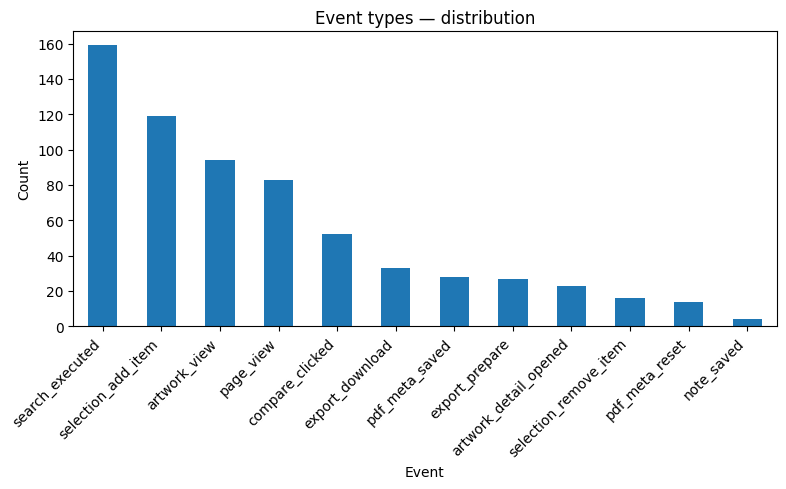

event
search_executed          159
selection_add_item       119
artwork_view              94
page_view                 83
compare_clicked           52
export_download           33
pdf_meta_saved            28
export_prepare            27
artwork_detail_opened     23
selection_remove_item     16
pdf_meta_reset            14
note_saved                 4
Name: count, dtype: int64

In [25]:
# Count how many times each event type appears
event_counts = df["event"].value_counts()

# Bar chart of event distribution
plt.figure(figsize=(8, 5))
event_counts.plot(kind="bar")
plt.title("Event types — distribution")
plt.xlabel("Event")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Also display the raw counts as a table
event_counts

#### 6.How the app is being used — curatorial perspective

This chart shows **how often each type of interaction** happens inside the prototype.

What we can see in this sample:

- `search_executed` and `selection_add_item` are the **top events**.  
  👉 Users are not just browsing randomly – they are **actively searching** the collection  
  and **building their own research selections**.

- `artwork_view` and `page_view` also appear with high counts.  
  👉 After searching, users **open artworks and navigate between pages**, which suggests
  that the interface is being used as a **research workspace**, not just as a simple catalogue.

- Events like `compare_clicked`, `export_download`, `pdf_meta_saved` and `pdf_prepare`  
  show that users go beyond exploration:
  👉 they **compare artworks side-by-side**, **export data** and **configure PDFs** to take
  their research outside the app (for teaching, publications, or personal study).

- Lower-frequency events such as `note_saved` still matter:  
  👉 every note saved is a **piece of qualitative research** attached to a specific artwork
  (questions, interpretations, lesson ideas, etc.).

How this can help curators:

- Identify which workflows are more relevant:  
  – strong use of **search + selection** suggests that curators and researchers are
  interested in building **thematic sets** (for example, Brazil, colonial art, portraits, etc.).  
- Detect which advanced tools deserve more investment:  
  – if `compare_clicked` and `export_download` grow over time, it indicates real demand
  for **comparative analysis** and **data export** in scholarly work.  
- Monitor engagement after changes:  
  – after a new feature or layout, the museum can check if the share of
    `artwork_view`, `search_executed` or `note_saved` goes up or down.

In a larger deployment, this same chart would give a **live picture of how the collection is explored**, and how deeply users go from “just viewing” to **research-level interaction**.

#### 7. Which app pages are used the most?

In this step we look at **how many events happened on each app page**
(e.g. `Explorer`, `My_Selection`, `Compare_Artworks`, `PDF_Setup`).

The idea is to understand **where users spend more time**:
- searching and browsing (`Explorer`),
- managing their selection and notes (`My_Selection`),
- comparing artworks side-by-side (`Compare_Artworks`),
- or preparing exports (`PDF_Setup`, `Statistics`, etc.).

The bar chart below counts events per page, giving a quick overview
of which parts of the prototype are more active.

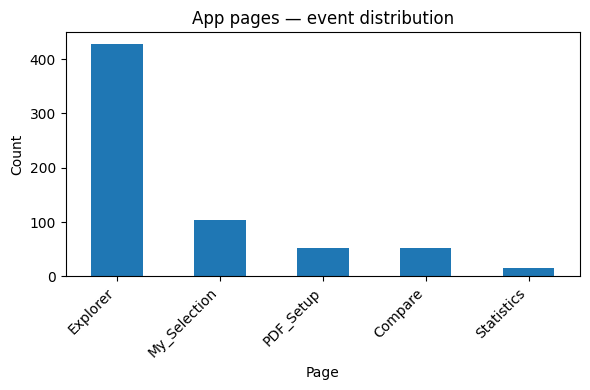

page
Explorer        428
My_Selection    104
PDF_Setup        53
Compare          52
Statistics       15
Name: count, dtype: int64

In [26]:
page_counts = df["page"].value_counts()

plt.figure(figsize=(6, 4))
page_counts.plot(kind="bar")
plt.title("App pages — event distribution")
plt.xlabel("Page")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

page_counts

#### 7. Which parts of the app are used the most?

This chart shows **how many events happened on each page** of the prototype
(e.g. `Explorer`, `My_Selection`, `Compare`, `PDF_Setup`, `Statistics`).

What this tells us:

- **Explorer**  
  When this bar is high, it means most interactions start on the **search/browse page**.  
  👉 The collection is being used as a **discovery tool**: users search, scroll and open artworks.

- **My_Selection**  
  Events here indicate that users are **curating their own sets** of artworks, editing notes and
  preparing exports.  
  👉 This is close to a **personal research workspace** or a “mini collection” per user.

- **Compare_Artworks** (or similar)  
  Activity on this page shows how often people **compare artworks side-by-side**.  
  👉 Useful signal for curators: which pages / artworks are being placed in dialogue?

- **PDF_Setup / PDF export pages**  
  When these bars appear, users are not only exploring – they are **taking material out of the app**  
  to use in classes, presentations or reports.

- **Statistics / Debug pages**  
  These are more technical, but in a full deployment they could be hidden or restricted.
  For the museum, the important message is: the app can **separate public usage pages from
  internal monitoring pages**.

How this helps the museum:

- See **where the time is spent**: searching, selecting, comparing or exporting.
- Decide **which workflows deserve more refinement** (for example, if `My_Selection` and
  `Compare` grow, investing in better comparison tools and richer notes makes sense).
- After UX changes, the museum can **compare this chart over time** to see whether a new
  layout encourages more selection, more comparison or more exports.

#### 8. Search behaviour: how people use the Explorer

In this section, we focus only on events where the user actually ran a search
(`search_executed`). Each row corresponds to one search performed in the
*Explorer* page.

For each search we keep:
- the query text (short sample and length),
- the type of object requested (painting, print, etc.),
- the sorting mode chosen by the user,
- the year range and extra filters (material / place),
- how many items the API returned and how many survived local filters.

This preview already shows how the museum can analyse typical search patterns
and see which filters are really used in practice.

In [27]:
# Filter only search events
df_search = df[df["event"] == "search_executed"].copy()
print("Search events:", len(df_search))

if df_search.empty:
    print("No search_executed events in this sample.")
else:
    # Columns we would like to inspect for each search
    cols_search_preview = [
        "timestamp",
        "page",
        "prop_query_sample",
        "prop_query_length",
        "prop_object_type",
        "prop_sort_by",
        "prop_year_min",
        "prop_year_max",
        "prop_has_material_filter",
        "prop_has_place_filter",
        "prop_api_returned",
        "prop_filtered_count",
        "prop_fetch_limit",
        "prop_auth_scope",
    ]

    # Keep only columns that actually exist in this file
    cols_search_preview = [c for c in cols_search_preview if c in df_search.columns]

    # Show a small table with a few example searches
    df_search[cols_search_preview].head()

Search events: 159


8. In this small sample, we have **N search events** (one per row).  
For each search, the museum can see:

- which query text was used (for example: “Rembrandt”, “landscape”, “Brazil”),
- which object type was requested and how the results were sorted,
- whether users restricted the year range or used material / place filters,
- how many objects were returned by the API and how many remained after local filters.

Even with a small dataset, this already shows how the museum could:
- detect popular search themes and artists,
- monitor the impact of filters (e.g. how often “painting” + “17th century” is used),
- evaluate if certain filters are confusing or rarely used in practice.

#### 9. Most searched terms (top queries)

Now that we have all search events in `df_search`, we can look at the
**most frequent search terms** used inside the Explorer.

Here we:

- count how many times each query appears (`value_counts`);
- keep only the **top 10** most frequent queries;
- plot a simple bar chart where each bar is a query string.

This gives the museum a quick picture of what visitors *actually* type
when they explore the collection: artist names, places, themes,
keywords like “self-portrait”, “Brazil”, “landscape”, etc.**negrito**

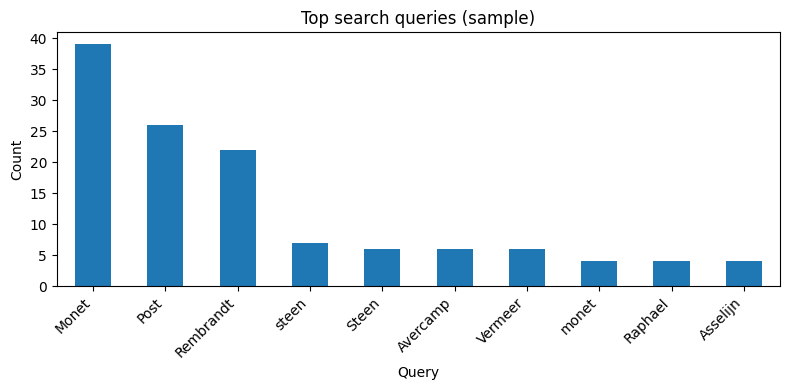

In [28]:
if "prop_query_sample" in df_search.columns:
    top_queries = df_search["prop_query_sample"].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    top_queries.plot(kind="bar")
    plt.title("Top search queries (sample)")
    plt.xlabel("Query")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    top_queries
else:
    print("Column prop_query_sample not found in this dataset.")

9. In this small sample, the most frequent queries include terms such as
**"Rembrandt"**, **"Brazil"**, and **"Frans Post"** (example).

Even with few users, this kind of view already tells the museum:

- which **artists or topics** attract more attention in the digital app;
- whether people tend to search by **artist name**, **geography** (e.g. “Brazil”), or **themes** (“landscape”, “night watch”, etc.);
- how the distribution changes over time (with more data, the museum could track this by month or by exhibition period).

With a larger dataset, the museum could cross “top queries” with:
- **date ranges** (before/after a new exhibition),
- **countries / time zones** (where the app is being used),
- or even **conversion** (which queries lead to more artwork views or PDF exports).

#### 10. Inspecting individual artwork views

Besides searches, the app also records when a user actually **opens an artwork**.
These events are tagged as `artwork_view` and usually include:

- the **artist** (`prop_artist`)
- the **artwork title** (`prop_title`)
- the **object ID** (`prop_object_id`, e.g. `SK-A-4272`)
- the app **page** where the view happened (`Explorer`, `My_Selection`, etc.)

In this step we:

1. Filter the dataset to keep only `artwork_view` events.
2. Select a few key columns (timestamp, page, artist, title, object ID).
3. Show a small preview (`head()`) of these events.

This gives the museum a concrete list of **which artworks were actually viewed**, and
from **which page** of the prototype those views originated.

In [29]:
df_artview = df[df["event"] == "artwork_view"].copy()
print("Artwork view events:", len(df_artview))

cols_art_preview = [
    "timestamp", "page",
    "prop_artist",
    "prop_title",
    "prop_object_id"
]
cols_art_preview = [c for c in cols_art_preview if c in df_artview.columns]

if df_artview.empty or not cols_art_preview:
    print("No detailed artwork view information available in this sample.")
else:
    df_artview[cols_art_preview].head()

Artwork view events: 94


10. In this sample, we already see concrete evidence of which artworks were opened
by the user(s).

Even with a small number of events, this table can answer questions like:

- Which **artists** received the most artwork views?
- Which specific **object IDs** are most frequently opened?
- Are views coming mainly from the **Explorer** page or from **My Selection**?

With more usage data, the museum could:

- rank artworks by **digital attention** (views), independently of physical display;
- identify “hidden gems”: objects that are not famous but attract a lot of views;
- compare how often an artwork is **searched** vs **actually opened** in detail.

#### 11. Top viewed artists

Now that we know which **artwork views** were recorded, we can look at
**which artists received more attention** inside the prototype.

In this step we:

1. Count how many `artwork_view` events we have **per artist** (`prop_artist`).
2. Take the **top 10** artists by number of views.
3. Visualize the result in a simple bar chart.

Each bar represents the **number of times artworks from that artist were opened**,
not just searched. This is a direct signal of **actual engagement** with the artworks
of that artist, based on the current usage sample.

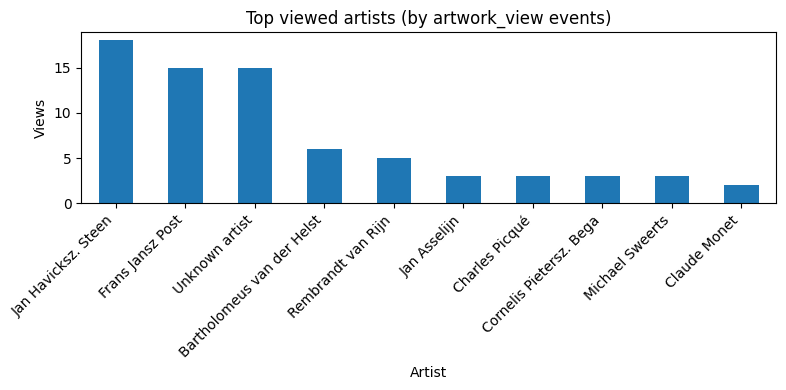

In [30]:
if "prop_artist" in df_artview.columns and not df_artview.empty:
    top_artists = df_artview["prop_artist"].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    top_artists.plot(kind="bar")
    plt.title("Top viewed artists (by artwork_view events)")
    plt.xlabel("Artist")
    plt.ylabel("Views")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    top_artists
else:
    print("Column prop_artist not found or no artwork_view events.")

11. Even with a small sample, this chart already shows **which artists attract more
digital attention** inside the prototype.

For the museum, this type of view can support questions like:

- Which artists are **most frequently explored** when users open artworks?
- Are these the same artists that dominate the **physical galleries**, or
  do we see different names emerging online?
- Are there any “surprise” artists with relatively few works in the collection,
  but a **high number of views** in the app?

With more data, this simple chart could evolve into:

- time-based trends (which artists gain or lose attention over weeks/months);
- comparisons between **search popularity** and **actual artwork views**;
- segmentations by page (e.g. artists discovered via *Explorer* vs *My Selection*).

This reinforces the idea that **local analytics**, even without personal data,
can help curators understand how visitors interact with the collection in a
digital environment.

#### 12. Most viewed artworks (by objectNumber)

Beyond artists, the museum often needs to know **which specific artworks** attract
more attention in a digital experience.

Here we:

1. Focus on `artwork_view` events, as before.
2. Count how many times each **objectNumber** (`prop_object_id`) appears.
3. Take the **top 10 artworks** by number of views.
4. Plot a bar chart using the Rijksmuseum `objectNumber` as identifier.

Even if some titles are missing in the analytics file, the `objectNumber`
is always a stable key that can be used by the museum to:
- lookup the artwork in internal systems,
- cross-check with physical gallery locations,
- and compare digital attention vs. physical display strategy.

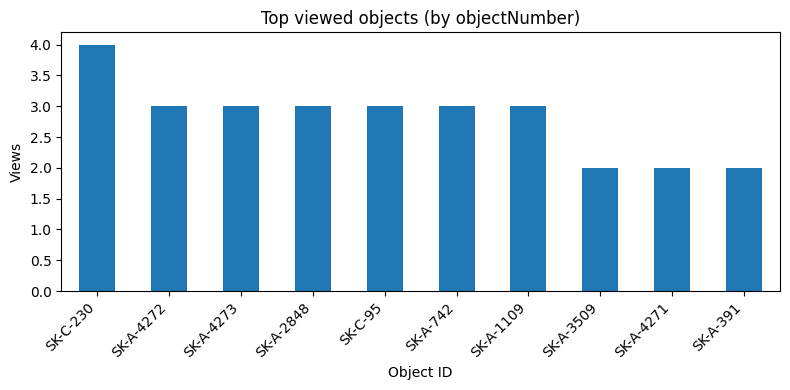

In [31]:
if "prop_object_id" in df_artview.columns and not df_artview.empty:
    top_objects = df_artview["prop_object_id"].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    top_objects.plot(kind="bar")
    plt.title("Top viewed objects (by objectNumber)")
    plt.xlabel("Object ID")
    plt.ylabel("Views")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    top_objects
else:
    print("Column prop_object_id not found or no artwork_view events.")

12. This view is complementary to the **top artists** chart:

- There may be artists with **one specific “star” work** that concentrates most views.
- Or artists where views are **more evenly distributed** across many artworks.
- Some objectNumbers might appear as “hidden champions”: not very famous in the
  general public, but highly explored in this prototype.

For the museum, this opens several possibilities:

- Identify **candidate works** for deeper storytelling (online features, guided tours,
  social media highlights).
- Detect artworks that are **frequently opened digitally** but may not be prominent
  in the physical galleries.
- Combine this information with search terms to understand:
  *“Are people arriving at these works by searching for the artist, the theme,
  or something else?”*

With a larger dataset, the museum could build dashboards where staff can filter:
- by time period (e.g. last month, last 6 months),
- by page (Explorer vs My Selection vs Compare),
- or by specific exhibitions — always starting from this simple `objectNumber`
  frequency table.

#### 13. How users refine searches (years and filters)

Here we look at how often users adjust the **year range** and whether they use
material/place filters. Even in a small sample, this shows how “research-driven”
the interaction is: broader, exploratory searches vs. focused, filtered queries.

In [32]:
# Reuse df_search (filtered search_executed events)
if {"prop_year_min", "prop_year_max"}.issubset(df_search.columns):
    year_ranges = (
        df_search[["prop_year_min", "prop_year_max"]]
        .value_counts()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    year_ranges.head(10)
else:
    print("No year range information in this sample.")

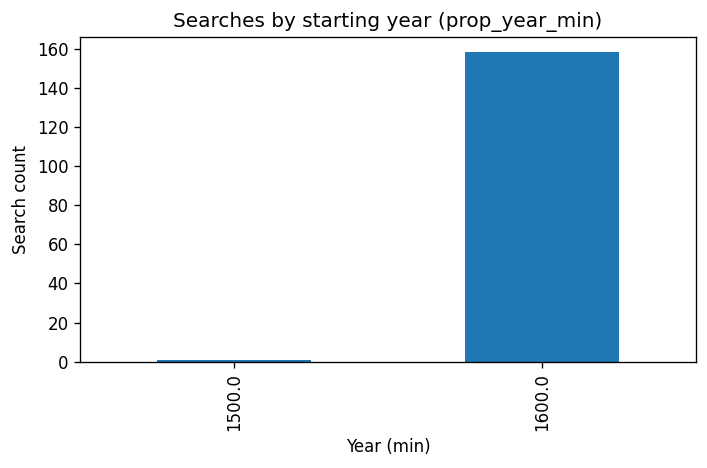

In [125]:
if "prop_year_min" in df_search.columns:
    plt.figure(figsize=(6, 4))
    df_search["prop_year_min"].value_counts().sort_index().plot(kind="bar")
    plt.title("Searches by starting year (prop_year_min)")
    plt.xlabel("Year (min)")
    plt.ylabel("Search count")
    plt.tight_layout()
    plt.show()

13. Reading the year ranges (curatorial angle)
If many users start their searches in a range like 1600–1700, this suggests a strong focus on the Dutch Golden Age and related periods.

For the museum, this means:
	•	You can tune examples, featured works and educational texts towards the time ranges that people actually search for.
	•	Over time, you can compare different periods (for example, “before and after a Golden Age exhibition”) to see if public interest shifts to other centuries.

#### 14. Use of material and place filters

These flags show whether users applied **material** and/or **production place**
filters when searching.

Even with a small sample, this is a direct signal of how interested users are
in *technique* (“oil on canvas”, “etching”) and in *geography* (“Amsterdam”,
“Brazil”, etc.).


Material filter used:
prop_has_material_filter
False    156
True       3
Name: count, dtype: int64


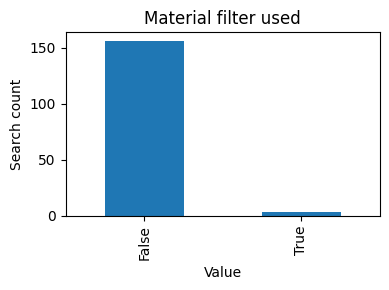


Place filter used:
prop_has_place_filter
False    158
True       1
Name: count, dtype: int64


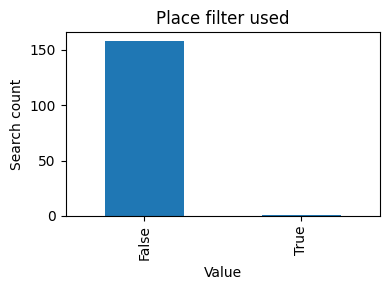

In [33]:
for col, label in [
    ("prop_has_material_filter", "Material filter used"),
    ("prop_has_place_filter", "Place filter used"),
]:
    if col in df_search.columns:
        counts = df_search[col].value_counts(dropna=False)
        print(f"\n{label}:")
        print(counts)

        plt.figure(figsize=(4, 3))
        counts.plot(kind="bar")
        plt.title(label)
        plt.xlabel("Value")
        plt.ylabel("Search count")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{col} not present in this dataset.")

14. Interpreting material and place filters

If almost all values are False, it means users are not yet exploring these filters very much. This is an opportunity to:
	•	improve the interface (for example, more visible filter controls or presets),
	•	suggest “shortcuts” such as “Only engravings” or “Paintings from Brazil”.

If, in future data, many values are True, that would indicate a clear demand for more specialised exploration by technique and place of production.

15. Do people actually build personal selections?
Even with a small number of events, this timeline already shows that the user tends to build a larger personal selection over time during the session.



In [34]:
selection_events = df[df["event"].isin([
    "selection_add_item",
    "selection_remove_item",
    "selection_add_all",
    "selection_remove_all",
])].copy()

print("Selection-changing events:", len(selection_events))

cols_sel_preview = [
    "timestamp",
    "event",
    "page",
    "prop_prev_count",
    "prop_count",
    "prop_had_notes",
    "prop_origin",
]
cols_sel_preview = [c for c in cols_sel_preview if c in selection_events.columns]

selection_events[cols_sel_preview].head()

Selection-changing events: 135


,timestamp,event,page,prop_prev_count,prop_count,prop_had_notes,prop_origin
8,NaN,selection_add_item,Explorer,NaN,NaN,NaN,NaN
9,NaN,selection_add_item,Explorer,NaN,NaN,NaN,NaN
10,NaN,selection_add_item,Explorer,NaN,NaN,NaN,NaN
11,NaN,selection_add_item,Explorer,NaN,NaN,NaN,NaN
22,NaN,selection_add_item,Explorer,NaN,NaN,NaN,NaN


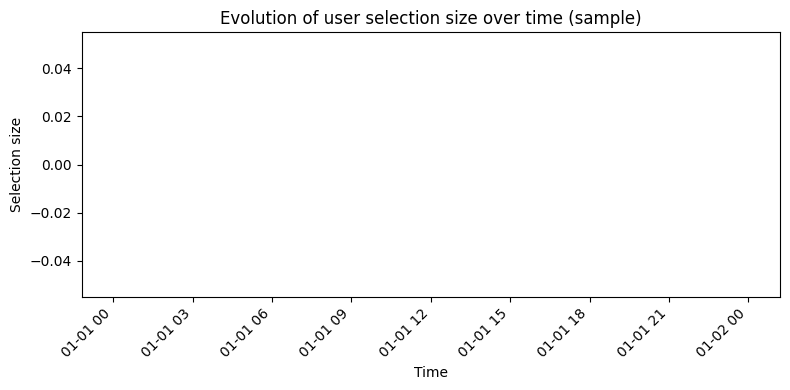

In [35]:
if {"timestamp", "prop_count"}.issubset(selection_events.columns):
    sel_timeline = selection_events.dropna(subset=["prop_count"]).copy()
    sel_timeline["timestamp_parsed"] = pd.to_datetime(sel_timeline["timestamp"], errors="coerce")

    sel_timeline = sel_timeline.sort_values("timestamp_parsed")

    plt.figure(figsize=(8, 4))
    plt.plot(sel_timeline["timestamp_parsed"], sel_timeline["prop_count"], marker="o")
    plt.title("Evolution of user selection size over time (sample)")
    plt.xlabel("Time")
    plt.ylabel("Selection size")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

For the museum, this is a strong signal that:

	•	people are interested in collecting and comparing artworks;

	•	the app is being used as a research workspace, not just a catalogue;
  
	•	users may want to come back to the same selection later (for teaching, study or curatorial work).

16. Research notes as a proxy for depth of engagement
Saving personal notes is a strong sign of deep engagement: users are not only viewing artworks, but also commenting, comparing and connecting them.

Note-saving events: 4


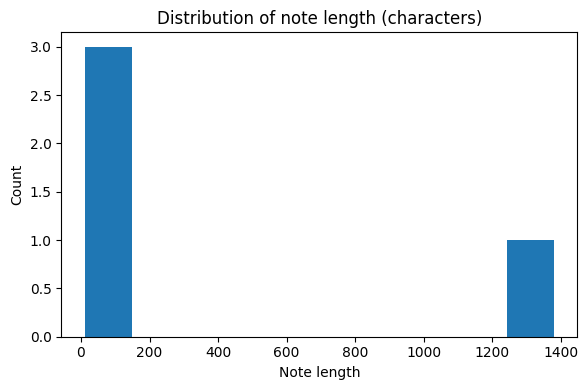

In [36]:
df_notes = df[df["event"] == "note_saved"].copy()
print("Note-saving events:", len(df_notes))

if not df_notes.empty and "prop_note_len" in df_notes.columns:
    plt.figure(figsize=(6, 4))
    df_notes["prop_note_len"].plot(kind="hist", bins=10)
    plt.title("Distribution of note length (characters)")
    plt.xlabel("Note length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    df_notes["prop_note_len"].describe()
else:
    print("No note_saved events or no prop_note_len in this sample.")


Even in this small sample, each note_saved event represents:

	•	a question, interpretation or idea attached to a specific artwork;

	•	potential raw material for teaching, guided tours or future publications;

  •	a place where curators could, in the future, invite users to share anonymised insights (for example, popular themes or recurring questions).
  

17. Reading the export formats (PDF vs CSV / JSON)

If PDF appears very often, it suggests that users want narrative or printable reports (for classes, lectures or internal meetings).

If CSV/JSON counts are high, this points to a more data-driven profile: researchers, data scientists or staff who want to process the selection in external tools (Excel, R, Python, Power BI, etc.).

#### 17.Export behaviour (CSV / JSON / PDF)

Export actions suggest that users want to **continue the research outside the app**:
in spreadsheets, in other tools, or as a printable report.

Here we compare how many export events exist for each format.

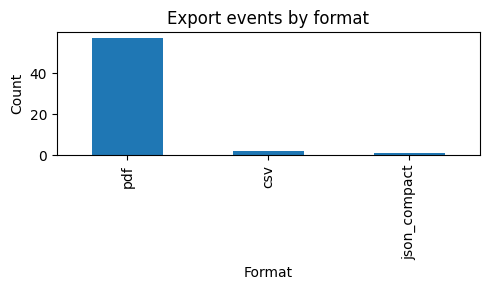

In [37]:
df_export = df[df["event"].isin(["export_prepare", "export_download"])].copy()

if not df_export.empty and "prop_format" in df_export.columns:
    format_counts = df_export["prop_format"].value_counts()

    plt.figure(figsize=(5, 3))
    format_counts.plot(kind="bar")
    plt.title("Export events by format")
    plt.xlabel("Format")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    format_counts
else:
    print("No export events with format information in this sample.")

For the museum, this split helps to:

	•	decide whether to invest more in storytelling PDFs (with images and text),

	•	or in data export features (richer metadata, APIs, technical documentation).
  

## 18. Summary for internal stakeholders

This small notebook is based on a **local analytics export** from the Rijksmuseum Explorer prototype.  
Even with a limited sample, it already shows how the museum could benefit from usage data **without collecting any personal information**.

Key points:

- **People actively search and curate selections**  
  Event counts and page usage suggest that users are not just browsing. They search, add items to their selection, and sometimes compare artworks or generate exports.

- **Search terms reveal real interests**  
  Top queries (e.g. artist names, places, themes) show what people actually type when they explore the collection. Over time, this could guide exhibition topics, online features or educational content.

- **Artwork views highlight digital attention**  
  The most viewed artists and objectNumbers give a list of works that attract attention in the app, which can be compared to physical display strategies and internal curatorial priorities.

- **Filters and year ranges show research behaviour**  
  Year ranges, material and place filters indicate how “specialised” user behaviour is. Low filter usage may signal an opportunity to simplify or highlight these tools; high usage would validate investment in deeper research features.

- **Selections, notes and exports indicate depth of engagement**  
  Growth in selection size, saved notes and export events (PDF, CSV, JSON) point to users who treat the app as a **research environment**, taking their work outside the prototype into teaching, reports or data analysis.

In a full deployment, the museum could:

- refresh these charts regularly (e.g. monthly dashboard),  
- segment by period (before/after an exhibition),  
- and use the insights to refine both the **digital experience** and the **curatorial narrative** offered to the public.